# Bombaci-Logoteta EOS

In this notebook we compare different versions of the Bombaci-Logoteta Baryotropic EOS. 
See also: [http://arxiv.org/abs/1805.11846](http://arxiv.org/abs/1805.11846)

In [1]:
# Load local package project environment 
using Pkg
Pkg.activate("./../..") 

# Import modules
using Plots
plotlyjs()

using EOSeNS.NEOS

  Activating project at `~/Desktop/GitRepositories/EOSeNS`


WebIO._IJuliaInit()

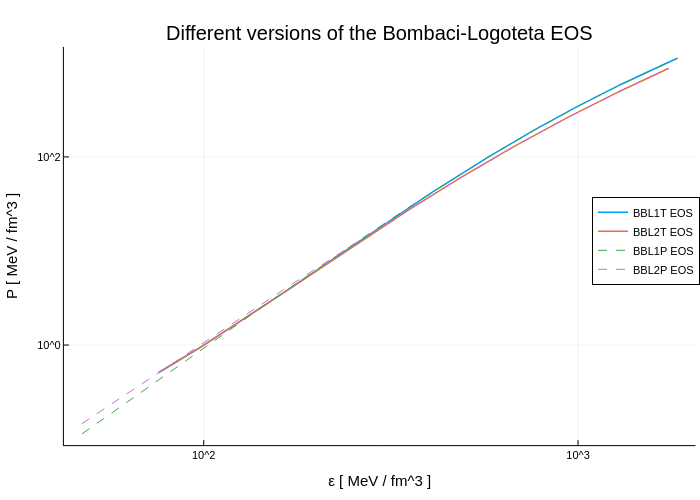

In [2]:
bbl1t =  bblTableEOS(1)
bbl2t =  bblTableEOS(2)
bbl1p =  bblPolytropeEOS(1, n_dense_min = 5e-2)
bbl2p =  bblPolytropeEOS(2, n_dense_min = 5e-2)

plot(bbl1t["energy_density"], bbl1t["pressure"], label = bbl1t.name , width = 1.5, xscale = :log10, yscale = :log10, legend = :right)
plot!(bbl2t["energy_density"], bbl2t["pressure"], label = bbl2t.name, width = 1.5)
plot!(bbl1p["energy_density"], bbl1p["pressure"], label = bbl1p.name, line = (1, (:dash)))
plot!(bbl2p["energy_density"], bbl2p["pressure"], label = bbl2p.name, line = (1, (:dash)))
xlabel!("ε [ MeV / fm^3 ]")
ylabel!("P [ MeV / fm^3 ]")
title!("Different versions of the Bombaci-Logoteta EOS")

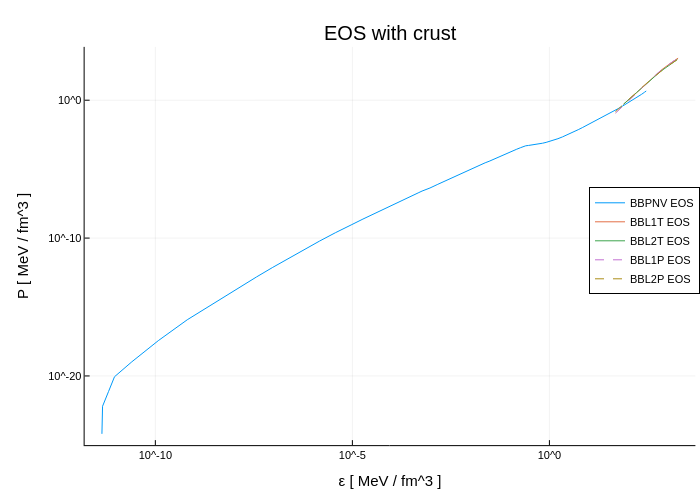

In [3]:
curst_eos = convertUnits(bbpnvCrustEOS(), NuclearUnits())

plot(curst_eos["energy_density"], curst_eos["pressure"], label = "BBPNV EOS" , xscale = :log10, yscale = :log10, legend = :right)
plot!(bbl1t["energy_density"], bbl1t["pressure"], label = bbl1t.name )
plot!(bbl2t["energy_density"], bbl2t["pressure"], label = bbl2t.name)
plot!(bbl1p["energy_density"], bbl1p["pressure"], label = bbl1p.name, line = (1, (:dash)))
plot!(bbl2p["energy_density"], bbl2p["pressure"], label = bbl2p.name, line = (1, (:dash)))
xlabel!("ε [ MeV / fm^3 ]")
ylabel!("P [ MeV / fm^3 ]")
title!("EOS with crust")

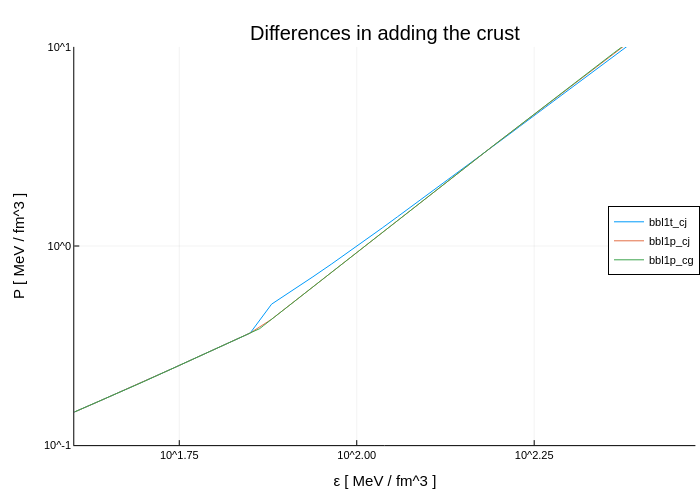

In [4]:
bbl1t_cj =  addCrustByJumping(bbl1t, 0.08)
bbl1p = bblPolytropeEOS(1, n_dense_min = 5e-2)
bbl1p_cj =  addCrustByJumping(bbl1p, 0.08)
bbl1p_cg =  addCrustByGlueing(bbl1p)

plot(bbl1t_cj["energy_density"], bbl1t_cj["pressure"], label = "bbl1t_cj",  xscale = :log10, yscale = :log10, legend = :right)
plot!(bbl1p_cj["energy_density"], bbl1p_cj["pressure"], label = "bbl1p_cj", xlim = (40,300), ylim = (0.1,10))
plot!(bbl1p_cg["energy_density"], bbl1p_cg["pressure"], label = "bbl1p_cg")
xlabel!("ε [ MeV / fm^3 ]")
ylabel!("P [ MeV / fm^3 ]")
title!("Differences in adding the crust")